## Importando os dados preparados

In [1]:
import joblib

partitions, anomalyColumns = joblib.load("./dados_preparados.pkl")

## Importando os pipelines

In [2]:
pipelines = joblib.load("./pipelines.pkl")
print(list(pipelines))

['IF', 'OCSVM', 'LOF']


## Imports

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_curve, roc_curve

from anomaly_utils import anomalyScores, evaluateQ95, extremeCases, scoreSummary

# Treinamento do modelo

## Isolation Forest

O pipeline é ajustado somente com `normalTrain`. O corte é fixo: **percentil 95 dos scores de
normalValidation**; aproximadamente 5% das True de validação o ultrapassam. Nenhuma Fake ou
notícia de teste define o threshold, e `contamination="auto"` não escolhe este corte.

In [4]:
result = evaluateQ95(pipelines["IF"], partitions, anomalyColumns)
threshold = result["threshold"]

testResultsFrame = result["testFrame"][["id", "label"] + anomalyColumns].copy()
testResultsFrame["anomalyScore"] = result["scores"]
testResultsFrame["isAnomaly"] = result["q95Flags"]
metrics = result["q95Metrics"]

print(f"Ajustado em {len(partitions['normalTrain'])} notícias True e 0 Fake.")
print(f"Threshold (percentil 95 de normalValidation): {threshold:.6f}")

Ajustado em 2160 notícias True e 0 Fake.
Threshold (percentil 95 de normalValidation): 0.115188


## Avaliação no teste

Classe positiva = **Fake (1)**, somente para medir discriminação. ROC-AUC e Average Precision (AP)
usam os scores contínuos; as demais métricas usam o sinal `isAnomaly`. A prevalência de Fake no
teste é o referencial de AP de uma ordenação aleatória.

In [5]:
display(scoreSummary(testResultsFrame, "anomalyScore"))
pd.Series(metrics, name="value").to_frame()

,class,count,mean,median,std,min,max
label,,,,,,,
0,True,720,-0.058204,-0.076152,0.061314,-0.125163,0.212721
1,Fake,1800,0.148692,0.142426,0.037844,-0.124589,0.261826


,value
rocAuc,0.980673
averagePrecision,0.988672
fakePrevalence,0.714286
tn,699.000000
fp,21.000000
fn,31.000000
tp,1769.000000
accuracy,0.979365
precision,0.988268
recall,0.982778


## Visualizações

True (0) em azul e Fake (1) em laranja. O primeiro painel mostra a validação apenas para inspeção;
os demais mostram o teste com o threshold escolhido em normalValidation.

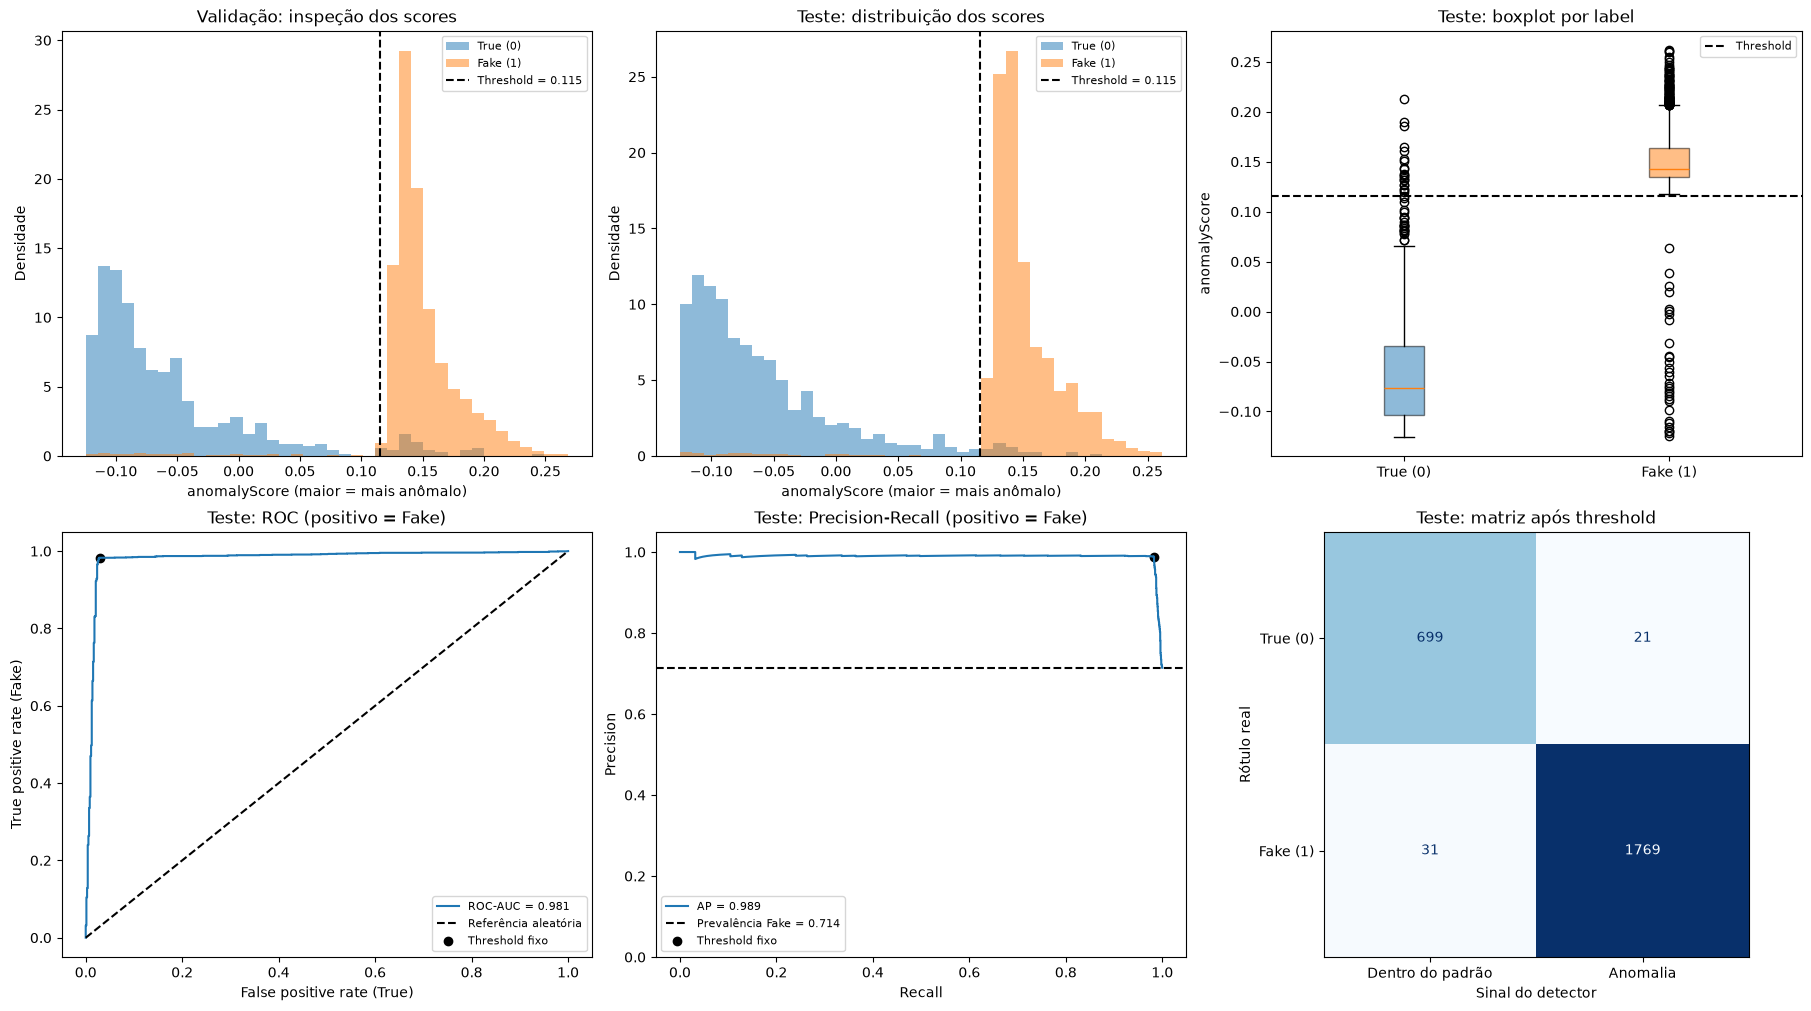

In [6]:
testLabels = testResultsFrame["label"].to_numpy()
testScores = testResultsFrame["anomalyScore"].to_numpy()
trueScores = testScores[testLabels == 0]
fakeScores = testScores[testLabels == 1]
fakeValidationScores = anomalyScores(result["pipeline"], partitions["fakeValidation"], anomalyColumns)

fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
for axis, groups, title in [
    (axes[0, 0], [result["normalValidationScores"], fakeValidationScores], "Validação: inspeção dos scores"),
    (axes[0, 1], [trueScores, fakeScores], "Teste: distribuição dos scores"),
]:
    bins = np.histogram_bin_edges(np.concatenate(groups), bins=40)
    for values, name, color in zip(groups, ["True (0)", "Fake (1)"], ["tab:blue", "tab:orange"]):
        axis.hist(values, bins=bins, density=True, alpha=0.5, label=name, color=color)
    axis.axvline(threshold, color="black", linestyle="--", label=f"Threshold = {threshold:.3f}")
    axis.set(title=title, xlabel="anomalyScore (maior = mais anômalo)", ylabel="Densidade")
    axis.legend(fontsize=8)

boxes = axes[0, 2].boxplot([trueScores, fakeScores], patch_artist=True)
for box, color in zip(boxes["boxes"], ["tab:blue", "tab:orange"]):
    box.set_facecolor(color)
    box.set_alpha(0.5)
axes[0, 2].set_xticks([1, 2], ["True (0)", "Fake (1)"])
axes[0, 2].axhline(threshold, color="black", linestyle="--", label="Threshold")
axes[0, 2].set(title="Teste: boxplot por label", ylabel="anomalyScore")
axes[0, 2].legend(fontsize=8)

rocFpr, rocTpr, _ = roc_curve(testLabels, testScores)
axes[1, 0].plot(rocFpr, rocTpr, label=f"ROC-AUC = {metrics['rocAuc']:.3f}")
axes[1, 0].plot([0, 1], [0, 1], "k--", label="Referência aleatória")
axes[1, 0].scatter([metrics["fpr"]], [metrics["recall"]], color="black", label="Threshold fixo")
axes[1, 0].set(title="Teste: ROC (positivo = Fake)", xlabel="False positive rate (True)", ylabel="True positive rate (Fake)")
axes[1, 0].legend(fontsize=8)

prPrecision, prRecall, _ = precision_recall_curve(testLabels, testScores)
axes[1, 1].plot(prRecall, prPrecision, label=f"AP = {metrics['averagePrecision']:.3f}")
axes[1, 1].axhline(metrics["fakePrevalence"], color="black", linestyle="--", label=f"Prevalência Fake = {metrics['fakePrevalence']:.3f}")
axes[1, 1].scatter([metrics["recall"]], [metrics["precision"]], color="black", label="Threshold fixo")
axes[1, 1].set(title="Teste: Precision-Recall (positivo = Fake)", xlabel="Recall", ylabel="Precision", ylim=(0, 1.05))
axes[1, 1].legend(fontsize=8)

ConfusionMatrixDisplay.from_predictions(
    testLabels, testResultsFrame["isAnomaly"].astype(int), display_labels=["True (0)", "Fake (1)"],
    ax=axes[1, 2], colorbar=False, cmap="Blues", values_format="d",
)
axes[1, 2].set_xticks([0, 1], ["Dentro do padrão", "Anomalia"])
axes[1, 2].set(title="Teste: matriz após threshold", xlabel="Sinal do detector", ylabel="Rótulo real")
axes[1, 2].grid(False)
plt.show()

## Casos extremos

Exemplos do teste. As features são exibidas antes da imputação; não são atribuições causais
nem importâncias do Isolation Forest.

In [7]:
for title, examples in extremeCases(testResultsFrame, "anomalyScore").items():
    display(Markdown(f"**{title}**"))
    display(examples)

**5 True mais anômalas**

,id,label,tem_autor,typeTokenRatio,linkDensity,punctuationDensity,uppercaseRatio,diversidade,anomalyScore,isAnomaly
0,262t,0,0,0.517241,0.0,0.293103,0.000000,0.731707,0.212721,True
1,133t,0,0,0.537313,0.0,0.223881,0.057692,0.692308,0.189983,True
2,3298t,0,1,0.426230,0.0,0.278689,0.000000,0.590909,0.185974,True
3,220t,0,0,0.612903,0.0,0.112903,0.054545,0.690909,0.164661,True
4,261t,0,0,0.649123,0.0,0.087719,0.038462,0.711538,0.160443,True


**5 Fake mais anômalas**

,id,label,tem_autor,typeTokenRatio,linkDensity,punctuationDensity,uppercaseRatio,diversidade,anomalyScore,isAnomaly
0,3386,1,0,0.642857,0.0,0.357143,0.111111,1.000000,0.261826,True
1,1834,1,0,0.540984,0.0,0.360656,0.128205,0.846154,0.261021,True
2,2910,1,0,0.535211,0.0,0.352113,0.130435,0.826087,0.259614,True
3,3325,1,0,0.544118,0.0,0.294118,0.333333,0.770833,0.254704,True
4,1005,1,0,0.445946,0.0,0.283784,0.056604,0.622642,0.252990,True


**5 Fake menos anômalas**

,id,label,tem_autor,typeTokenRatio,linkDensity,punctuationDensity,uppercaseRatio,diversidade,anomalyScore,isAnomaly
0,38,1,1,0.690909,0.0,0.145455,0.000000,0.808511,-0.124589,False
1,26,1,1,0.706897,0.0,0.137931,0.000000,0.820000,-0.121712,False
2,1,1,1,0.683333,0.0,0.133333,0.019231,0.788462,-0.119707,False
3,67,1,1,0.714286,0.0,0.142857,0.000000,0.833333,-0.119610,False
4,61,1,1,0.689655,0.0,0.120690,0.019608,0.784314,-0.115087,False


## Conclusão

In [8]:
display(Markdown(f"""
Foram treinadas **{len(partitions['normalTrain'])} notícias True e nenhuma Fake**.
No teste: **{metrics['tp']}/{metrics['tp'] + metrics['fn']} Fake detectadas** e
**{metrics['fp']}/{metrics['tn'] + metrics['fp']} True sinalizadas**.
ROC-AUC: **{metrics['rocAuc']:.4f}**; recall **{metrics['recall']:.2%}**; FPR **{metrics['fpr']:.2%}**.
Corte: **{threshold:.6f}**, calibrado apenas em True. **Anomalia não comprova falsidade.**
"""))


Foram treinadas **2160 notícias True e nenhuma Fake**.
No teste: **1769/1800 Fake detectadas** e
**21/720 True sinalizadas**.
ROC-AUC: **0.9807**; recall **98.28%**; FPR **2.92%**.
Corte: **0.115188**, calibrado apenas em True. **Anomalia não comprova falsidade.**
